# Question

**This project studies how simple local battery-dispatch rules create aggregate feeder stress, and how different coordination strategies change peak load, ramping, violations, and overload severity under different operating regimes.**


# Part 1 — Single-scenario comparison

**Study of how simple coordination mechanisms affect aggregate feeder behavior.**


### Purpose:
	- Introduce the system
	- How the behavior visually
	- Establish the mechanism

## Setup

**All experiments. in part 1, use identical data for fair comparison.**

- 5 batteries
- 24 timesteps (a day) 
- Synthetic load profiles
- Time-of-use price signal
- Feeder limit: 60 kW

In [231]:
# Import necessary libraries

import sys
sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

from src.battery import Battery
from src.controllers import (
    tou_controller,
    randomized_tou_controller,
    capped_tou_controller,
    soft_capped_tou_controller,
)
from src.simulator import (
    run_simulation,
    compute_peak_kw,
    compute_max_ramp_kw,
    count_feeder_violations,
    compute_total_feeder_excess_kw,
)

In [232]:
# Recreate the same random data for reproducibility

np.random.seed(42)

n_steps = 24
n_batteries = 5
feeder_limit_kw = 60.0

loads = np.random.uniform(5, 15, size=(n_steps, n_batteries))
prices = np.linspace(10, 100, n_steps)

def make_batteries():
    return [
        Battery(capacity_kwh=50, max_charge_kw=10, max_discharge_kw=10)
        for _ in range(n_batteries)
    ]

In [233]:
# Run experiments for each controller and collect results
def run_exp(controller):
    return run_simulation(
        load_profiles_kw=loads,
        prices=prices,
        batteries=make_batteries(),
        controller=controller,
        dt_hours=1.0,
        low_threshold=30,
        high_threshold=70,
        feeder_limit_kw=feeder_limit_kw,
    )

res_tou = run_exp(tou_controller)

res_rand = run_exp(
    lambda **kwargs: randomized_tou_controller(**kwargs, randomness=0.6)
)

res_cap = run_exp(capped_tou_controller)

res_soft = run_exp(
    lambda **kwargs: soft_capped_tou_controller(**kwargs, softness=0.3)
)

In [234]:
# Summarize results

def summarize(name, res):
    return {
        "Peak": compute_peak_kw(res.aggregate_load_kw),
        "Ramp": compute_max_ramp_kw(res.aggregate_load_kw),
        "Violations": count_feeder_violations(res.feeder_violations),
        "Total Excess": compute_total_feeder_excess_kw(
            res.aggregate_load_kw, feeder_limit_kw
        ),
    }

results = {
    "TOU": summarize("TOU", res_tou),
    "Randomized": summarize("Randomized", res_rand),
    "Capped": summarize("Capped", res_cap),
    "Soft": summarize("Soft", res_soft),
}

results

{'TOU': {'Peak': 103.11925491708158,
  'Ramp': 48.5681670497294,
  'Violations': 4,
  'Total Excess': 107.53306883441046},
 'Randomized': {'Peak': 93.11925491708158,
  'Ramp': 43.484884614599174,
  'Violations': 5,
  'Total Excess': 83.57305279357993},
 'Capped': {'Peak': 69.01107058283867,
  'Ramp': 48.5681670497294,
  'Violations': 7,
  'Total Excess': 43.61177674325382},
 'Soft': {'Peak': 66.76943721928596,
  'Ramp': 45.835721218854474,
  'Violations': 1,
  'Total Excess': 6.769437219285962}}

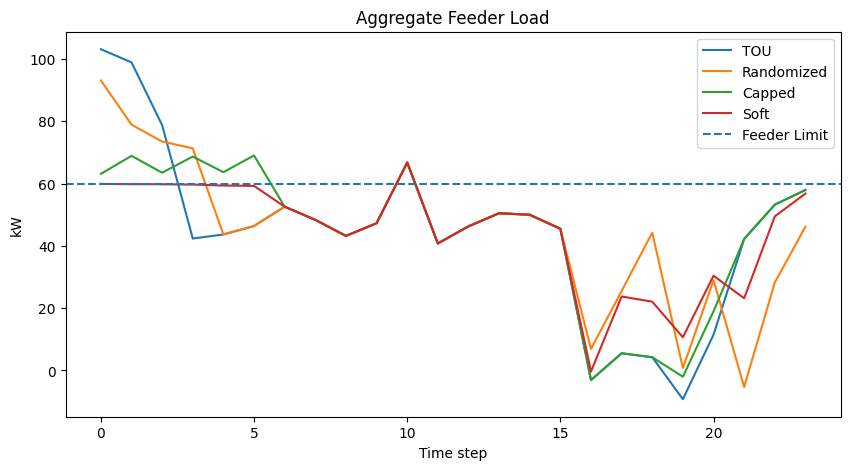

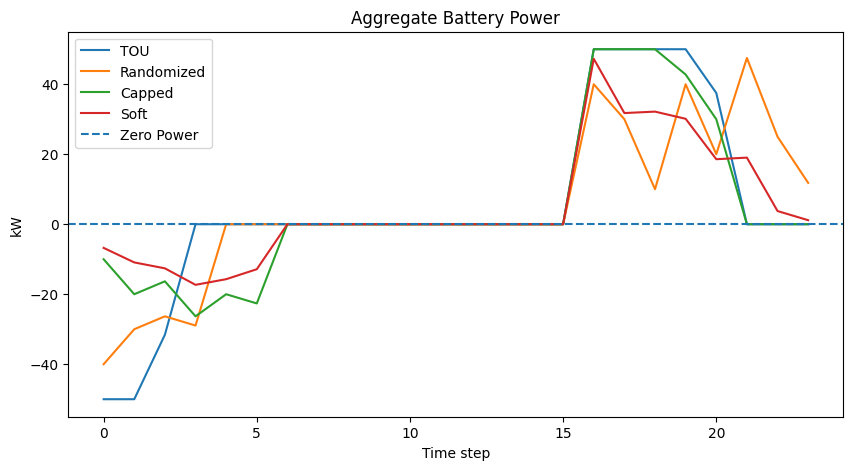

In [235]:
# Visualize aggregate load profiles

plt.figure(figsize=(10, 5))

plt.plot(res_tou.aggregate_load_kw, label="TOU")
plt.plot(res_rand.aggregate_load_kw, label="Randomized")
plt.plot(res_cap.aggregate_load_kw, label="Capped")
plt.plot(res_soft.aggregate_load_kw, label="Soft")

plt.axhline(feeder_limit_kw, linestyle="--", label="Feeder Limit")

plt.legend()
plt.title("Aggregate Feeder Load")
plt.xlabel("Time step")
plt.ylabel("kW")
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(res_tou.aggregate_battery_power_kw, label="TOU")
plt.plot(res_rand.aggregate_battery_power_kw, label="Randomized")
plt.plot(res_cap.aggregate_battery_power_kw, label="Capped")
plt.plot(res_soft.aggregate_battery_power_kw, label="Soft")

plt.axhline(0, linestyle="--", label="Zero Power")

plt.legend()
plt.title("Aggregate Battery Power")
plt.xlabel("Time step")
plt.ylabel("kW")
plt.show()

## Aggregate Feeder  Interpretation

- TOU leads to strong synchronization -> high peaks
- Randomization reduces peak and ramp but increases violations
- Hard cap reduces severity but introduces frequent threshold crossings
- Soft coordination achieves the best tradeoff:
  - low peak
  - near-zero violations
  - minimal excess

## Aggregate Battery Power Interpretation

**This plot shows how the battery fleet acts under each coordination strategy.**

- TOU tends to align battery actions strongly, creating synchronized charging/discharging behavior.
- Randomization breaks some of that alignment, reducing the strongest collective moves.
- Hard capping suppresses battery action abruptly when feeder stress is high.
- Soft coordination scales actions more gradually, which helps avoid large synchronized responses while still preserving useful battery support.

# Conclusion (Part 1)

In this experiment, soft coordination provided the best balance across the selected feeder stress metrics.

- Uncoordinated TOU produced the strongest synchronized peaks and the largest overload severity.
- Randomization reduced synchronization intensity, but still resulted in repeated violations.
- Hard capping reduced severe overloads, but introduced rigid near-limit behavior.
- Soft coordination achieved the most balanced outcome, reducing peak load, limiting violations, and minimizing total excess above the feeder limit.

### Why a Sweep Is Needed

    - The initial controller comparison shows that coordination can strongly affect aggregate feeder behavior in a single scenario.

    - However, a single scenario is not enough to determine whether one controller is consistently best. To test robustness, the next section studies how controller performance changes as the number of batteries and feeder constraints vary.

# Part 2 — Sweep analysis

### Purpose: Identify controller tradeoffs and regime changes.
	- Test whether the first result generalizes
    - Show regime transition
	- Refine the conclusion

**This section analyzes the full parameter sweep over:**
- battery count
- feeder limit
- controller type


In [236]:
from pathlib import Path
import pandas as pd

results_path = Path("../results/basic_run_results.csv").resolve()
df = pd.read_csv(results_path)
df

,n_batteries,feeder_limit_kw,controller,peak,ramp,violations,total_excess
0,5,50.0,Experiment 1 - TOU,103.119255,43.283736,8,141.931892
1,5,50.0,Experiment 2 - Randomized TOU,83.119255,33.283736,8,123.988821
2,5,50.0,Experiment 3 - Capped TOU,58.983327,61.881732,15,67.329340
3,5,50.0,Experiment 4 - Soft Capped TOU,56.948669,25.667337,5,21.532163
4,5,60.0,Experiment 1 - TOU,103.119255,43.283736,3,91.554475
5,5,60.0,Experiment 2 - Randomized TOU,83.119255,31.881732,3,36.291317
6,5,60.0,Experiment 3 - Capped TOU,69.512830,43.283736,6,31.089143
7,5,60.0,Experiment 4 - Soft Capped TOU,59.880677,33.813114,0,0.000000
8,5,80.0,Experiment 1 - TOU,103.119255,43.283736,2,36.778487
9,5,80.0,Experiment 2 - Randomized TOU,93.119255,19.460023,1,13.119255


In [237]:
#------------------------------------------------------------------------
# Map long controller names to short ones for better visualization
#------------------------------------------------------------------------

name_map = {
    "Experiment 1 - TOU": "TOU",
    "Experiment 2 - Randomized TOU": "Randomized",
    "Experiment 3 - Capped TOU": "Capped",
    "Experiment 4 - Soft Capped TOU": "Soft",
}

df["controller_short"] = df["controller"].map(name_map)
df

,n_batteries,feeder_limit_kw,controller,peak,ramp,violations,total_excess,controller_short
0,5,50.0,Experiment 1 - TOU,103.119255,43.283736,8,141.931892,TOU
1,5,50.0,Experiment 2 - Randomized TOU,83.119255,33.283736,8,123.988821,Randomized
2,5,50.0,Experiment 3 - Capped TOU,58.983327,61.881732,15,67.329340,Capped
3,5,50.0,Experiment 4 - Soft Capped TOU,56.948669,25.667337,5,21.532163,Soft
4,5,60.0,Experiment 1 - TOU,103.119255,43.283736,3,91.554475,TOU
5,5,60.0,Experiment 2 - Randomized TOU,83.119255,31.881732,3,36.291317,Randomized
6,5,60.0,Experiment 3 - Capped TOU,69.512830,43.283736,6,31.089143,Capped
7,5,60.0,Experiment 4 - Soft Capped TOU,59.880677,33.813114,0,0.000000,Soft
8,5,80.0,Experiment 1 - TOU,103.119255,43.283736,2,36.778487,TOU
9,5,80.0,Experiment 2 - Randomized TOU,93.119255,19.460023,1,13.119255,Randomized


In [238]:
#----------------------------------------------------------------------------------------------------------------
# For each scenario (battery count + feeder limit), find the controller with the best performance for each metric
#----------------------------------------------------------------------------------------------------------------

scenario_cols = ["n_batteries", "feeder_limit_kw"]

peak_winners = df.loc[df.groupby(scenario_cols)["peak"].idxmin(), scenario_cols + ["controller_short", "peak"]]
ramp_winners = df.loc[df.groupby(scenario_cols)["ramp"].idxmin(), scenario_cols + ["controller_short", "ramp"]]
viol_winners = df.loc[df.groupby(scenario_cols)["violations"].idxmin(), scenario_cols + ["controller_short", "violations"]]
excess_winners = df.loc[df.groupby(scenario_cols)["total_excess"].idxmin(), scenario_cols + ["controller_short", "total_excess"]]

peak_winners = peak_winners.rename(columns={"controller_short": "best_peak_controller"})
ramp_winners = ramp_winners.rename(columns={"controller_short": "best_ramp_controller"})
viol_winners = viol_winners.rename(columns={"controller_short": "best_violations_controller"})
excess_winners = excess_winners.rename(columns={"controller_short": "best_excess_controller"})

winner_summary = (
    peak_winners[["n_batteries", "feeder_limit_kw", "best_peak_controller", "peak"]]
    .merge(ramp_winners[["n_batteries", "feeder_limit_kw", "best_ramp_controller", "ramp"]], on=scenario_cols)
    .merge(viol_winners[["n_batteries", "feeder_limit_kw", "best_violations_controller", "violations"]], on=scenario_cols)
    .merge(excess_winners[["n_batteries", "feeder_limit_kw", "best_excess_controller", "total_excess"]], on=scenario_cols)
    .sort_values(scenario_cols)
)

winner_summary

,n_batteries,feeder_limit_kw,best_peak_controller,peak,best_ramp_controller,ramp,best_violations_controller,violations,best_excess_controller,total_excess
0,5,50.0,Soft,56.948669,Soft,25.667337,Soft,5,Soft,21.532163
1,5,60.0,Soft,59.880677,Randomized,31.881732,Soft,0,Soft,0.000000
2,5,80.0,Soft,78.045396,Randomized,19.460023,Soft,0,Soft,0.000000
3,10,50.0,Capped,123.346538,Capped,22.488563,TOU,19,Soft,1028.966475
4,10,60.0,Capped,123.346538,Capped,22.488563,TOU,19,Soft,817.691723
5,10,80.0,Capped,123.346538,Capped,22.488563,Randomized,17,Soft,357.363258
6,20,50.0,Capped,232.928640,Capped,55.014631,TOU,20,Soft,3209.577572
7,20,60.0,Capped,232.928640,Capped,55.014631,TOU,19,Soft,2983.692235
8,20,80.0,Capped,232.928640,Capped,55.014631,TOU,19,Soft,2528.554999


In [239]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot tables to visualize excess performance across scenarios
#----------------------------------------------------------------------------------------------------------------

pivot_excess = df.pivot_table(
    index=["n_batteries", "controller_short"],
    columns="feeder_limit_kw",
    values="total_excess"
).sort_index()

pivot_excess

feeder_limit_kw                      50.0         60.0         80.0
n_batteries controller_short                                       
5           Capped              67.329340    31.089143     8.922896
            Randomized         123.988821    36.291317    13.119255
            Soft                21.532163     0.000000     0.000000
            TOU                141.931892    91.554475    36.778487
10          Capped            1192.921370   952.921370   472.921370
            Randomized        1083.066071   918.251760   522.979469
            Soft              1028.966475   817.691723   357.363258
            TOU               1192.893896  1002.893896   622.893896
20          Capped            3582.407139  3342.407139  2862.407139
            Randomized        3269.737123  3010.550374  2560.773812
            Soft              3209.577572  2983.692235  2528.554999
            TOU               3361.520273  3162.818882  2782.818882

In [240]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot tables to visualize violations across scenarios
#----------------------------------------------------------------------------------------------------------------

pivot_viol = df.pivot_table(
    index=["n_batteries", "controller_short"],
    columns="feeder_limit_kw",
    values="violations"
).sort_index()

pivot_viol

feeder_limit_kw               50.0  60.0  80.0
n_batteries controller_short                  
5           Capped            15.0   6.0   3.0
            Randomized         8.0   3.0   1.0
            Soft               5.0   0.0   0.0
            TOU                8.0   3.0   2.0
10          Capped            24.0  24.0  24.0
            Randomized        21.0  20.0  17.0
            Soft              21.0  21.0  19.0
            TOU               19.0  19.0  19.0
20          Capped            24.0  24.0  24.0
            Randomized        23.0  22.0  22.0
            Soft              22.0  22.0  22.0
            TOU               20.0  19.0  19.0

In [ ]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot tables to visualize peak performance across scenarios
#----------------------------------------------------------------------------------------------------------------

pivot_peak = df.pivot_table(
    index=["n_batteries", "controller_short"],
    columns="feeder_limit_kw",
    values="peak"
).sort_index()
pivot_peak

feeder_limit_kw                     50.0        60.0        80.0
n_batteries controller_short                                    
5           Capped             58.983327   69.512830   83.659232
            Randomized         83.119255   83.119255   93.119255
            Soft               56.948669   59.880677   78.045396
            TOU               103.119255  103.119255  103.119255
10          Capped            123.346538  123.346538  123.346538
            Randomized        162.013674  166.771491  149.368644
            Soft              123.346538  123.346538  123.346538
            TOU               202.013674  202.013674  202.013674
20          Capped            232.928640  232.928640  232.928640
            Randomized        341.540458  330.965793  340.965793
            Soft              232.928640  232.928640  232.928640
            TOU               391.540458  391.540458  391.540458


In [242]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot tables to visualize ramp performance across scenarios
#----------------------------------------------------------------------------------------------------------------

pivot_ramp = df.pivot_table(
    index=["n_batteries", "controller_short"],
    columns="feeder_limit_kw",
    values="ramp"
).sort_index()

pivot_ramp

feeder_limit_kw                     50.0        60.0        80.0
n_batteries controller_short                                    
5           Capped             61.881732   43.283736   43.283736
            Randomized         33.283736   31.881732   19.460023
            Soft               25.667337   33.813114   43.038656
            TOU                43.283736   43.283736   43.283736
10          Capped             22.488563   22.488563   22.488563
            Randomized         37.558567   54.271250   66.381981
            Soft               74.507127   68.263958   54.589098
            TOU                96.381981   96.381981   96.381981
20          Capped             55.014631   55.014631   55.014631
            Randomized        152.023638  132.023638  132.023638
            Soft              196.383377  193.491485  186.480458
            TOU               202.023638  202.023638  202.023638

In [243]:
#----------------------------------------------------------------------------------------------------------------
# Count how many times each controller wins for each metric across all scenarios
#----------------------------------------------------------------------------------------------------------------

win_counts = pd.DataFrame({
    "peak_wins": winner_summary["best_peak_controller"].value_counts(),
    "ramp_wins": winner_summary["best_ramp_controller"].value_counts(),
    "violations_wins": winner_summary["best_violations_controller"].value_counts(),
    "excess_wins": winner_summary["best_excess_controller"].value_counts(),
}).fillna(0).astype(int)

win_counts

,peak_wins,ramp_wins,violations_wins,excess_wins
Capped,6,6,0,0
Randomized,0,2,1,0
Soft,3,1,3,9
TOU,0,0,5,0


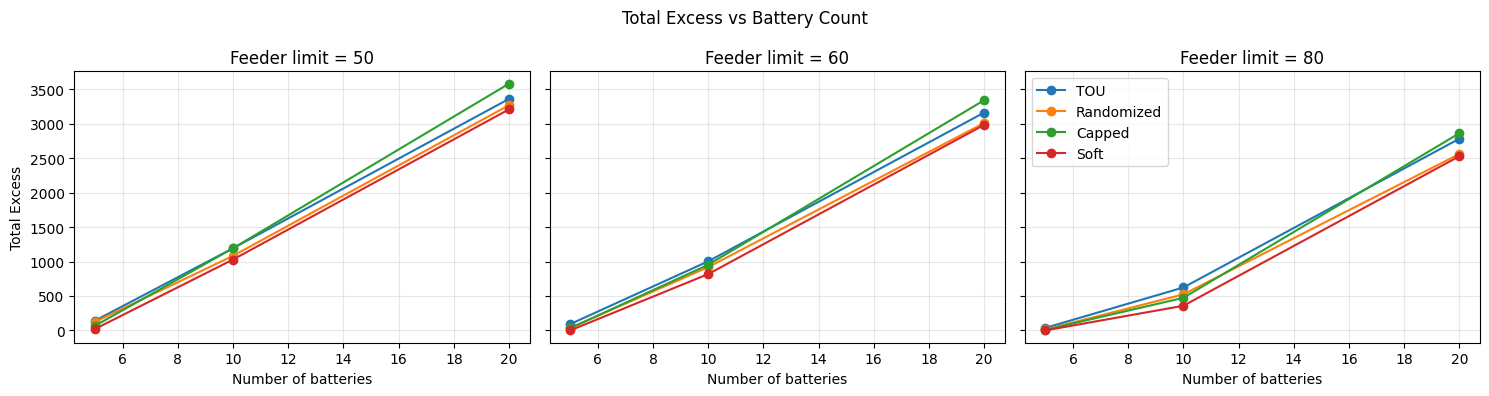

In [244]:
# Total Excess vs Battery Count
#----------------------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt

controllers_order = ["TOU", "Randomized", "Capped", "Soft"]
feeder_limits = sorted(df["feeder_limit_kw"].unique())
battery_counts = sorted(df["n_batteries"].unique())

fig, axes = plt.subplots(1, len(feeder_limits), figsize=(15, 4), sharey=True)

for ax, feeder_limit in zip(axes, feeder_limits):
    subset = df[df["feeder_limit_kw"] == feeder_limit]
    
    for controller in controllers_order:
        s = subset[subset["controller_short"] == controller].sort_values("n_batteries")
        ax.plot(
            s["n_batteries"],
            s["total_excess"],
            marker="o",
            label=controller,
        )
    
    ax.set_title(f"Feeder limit = {feeder_limit:.0f}")
    ax.set_xlabel("Number of batteries")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Total Excess")
axes[-1].legend()
plt.suptitle("Total Excess vs Battery Count")
plt.tight_layout()
plt.show()

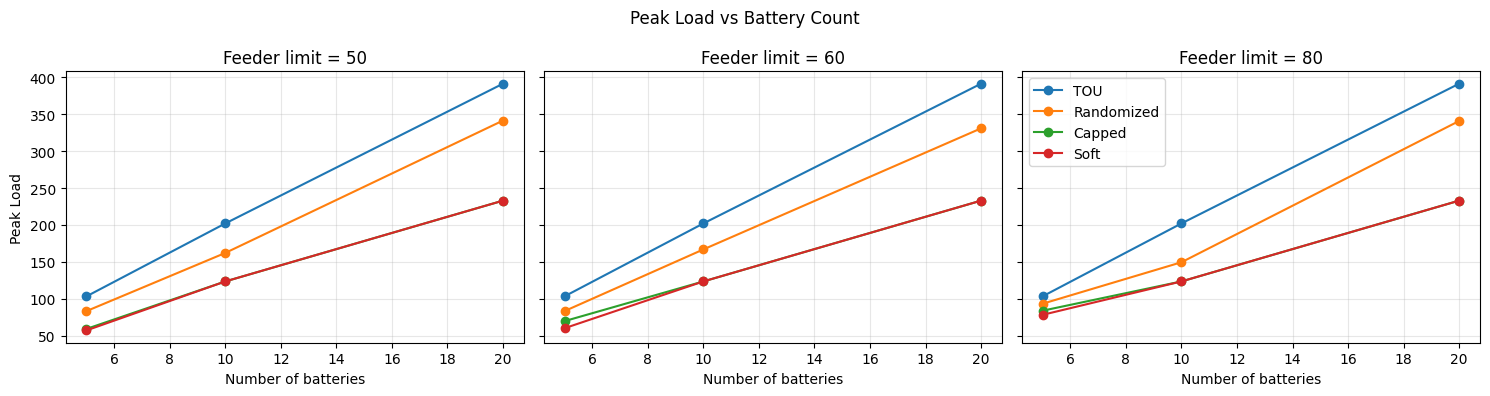

In [245]:
#Peak vs Battery Count
#----------------------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, len(feeder_limits), figsize=(15, 4), sharey=True)

for ax, feeder_limit in zip(axes, feeder_limits):
    subset = df[df["feeder_limit_kw"] == feeder_limit]
    
    for controller in controllers_order:
        s = subset[subset["controller_short"] == controller].sort_values("n_batteries")
        ax.plot(
            s["n_batteries"],
            s["peak"],
            marker="o",
            label=controller,
        )
    
    ax.set_title(f"Feeder limit = {feeder_limit:.0f}")
    ax.set_xlabel("Number of batteries")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Peak Load")
axes[-1].legend()
plt.suptitle("Peak Load vs Battery Count")
plt.tight_layout()
plt.show()

## Sweep Conclusions

The sweep reveals a clear regime transition.

- In light regimes (n_batteries = 5), soft coordination performs best overall, often eliminating feeder violations while also reducing peak load and cumulative excess.
- In medium and hard regimes (n_batteries = 10, 20), no controller dominates all metrics.
- Hard capping is strongest for reducing peak and ramp, especially as system stress increases.
- Soft coordination is strongest for reducing total excess, and is the only controller that consistently minimizes overload severity across all scenarios.
- Violation count alone is insufficient for evaluation, since a controller may produce fewer violations but much larger cumulative overload.
- In severe regimes, simple coordination does not fully solve the problem; instead, it changes how the system fails.

# Part 3 : Softness Sweep

    - This section studies whether the soft controller's behavior depends on thesoftness parameter.

### The sweep is performed on three representative regimes:

- light: 5 batteries, feeder limit 60
- medium: 10 batteries, feeder limit 60
- hard: 20 batteries, feeder limit 80

**For each regime, the baseline TOU controller is compared against Soft Capped TOU with:**

- softness = 0.1
- softness = 0.3
- softness = 0.5

## Purpose:
    - Understand whether the soft controller is robust to parameter changes and whether the effect of softness depends on regime severity.

In [246]:
from pathlib import Path
import pandas as pd

softness_path = Path("../results/softness_sweep_results.csv").resolve()
print("Looking for:", softness_path)

soft_df = pd.read_csv(softness_path)
soft_df

Looking for: /Users/linearityproductions/Desktop/risk_dispatch/results/softness_sweep_results.csv


,scenario,n_batteries,feeder_limit_kw,controller,softness,peak,ramp,violations,total_excess
0,light,5,60.0,Baseline - TOU,NaN,103.119255,43.283736,3,91.554475
1,light,5,60.0,Soft Capped TOU,0.1,63.675222,38.970083,6,15.413194
2,light,5,60.0,Soft Capped TOU,0.3,59.880677,33.813114,0,0.000000
3,light,5,60.0,Soft Capped TOU,0.5,59.093894,41.874023,0,0.000000
4,medium,10,60.0,Baseline - TOU,NaN,202.013674,96.381981,19,1002.893896
5,medium,10,60.0,Soft Capped TOU,0.1,123.346538,90.879950,22,829.944458
6,medium,10,60.0,Soft Capped TOU,0.3,123.346538,68.263958,21,817.691723
7,medium,10,60.0,Soft Capped TOU,0.5,123.346538,55.055841,20,768.138629
8,hard,20,80.0,Baseline - TOU,NaN,391.540458,202.023638,19,2782.818882
9,hard,20,80.0,Soft Capped TOU,0.1,232.928640,202.023638,22,2561.468499


In [247]:
soft_df["controller_short"] = soft_df["controller"].replace({
    "Baseline - TOU": "TOU",
    "Soft Capped TOU": "Soft",
})

soft_df

,scenario,n_batteries,feeder_limit_kw,controller,softness,peak,ramp,violations,total_excess,controller_short
0,light,5,60.0,Baseline - TOU,NaN,103.119255,43.283736,3,91.554475,TOU
1,light,5,60.0,Soft Capped TOU,0.1,63.675222,38.970083,6,15.413194,Soft
2,light,5,60.0,Soft Capped TOU,0.3,59.880677,33.813114,0,0.000000,Soft
3,light,5,60.0,Soft Capped TOU,0.5,59.093894,41.874023,0,0.000000,Soft
4,medium,10,60.0,Baseline - TOU,NaN,202.013674,96.381981,19,1002.893896,TOU
5,medium,10,60.0,Soft Capped TOU,0.1,123.346538,90.879950,22,829.944458,Soft
6,medium,10,60.0,Soft Capped TOU,0.3,123.346538,68.263958,21,817.691723,Soft
7,medium,10,60.0,Soft Capped TOU,0.5,123.346538,55.055841,20,768.138629,Soft
8,hard,20,80.0,Baseline - TOU,NaN,391.540458,202.023638,19,2782.818882,TOU
9,hard,20,80.0,Soft Capped TOU,0.1,232.928640,202.023638,22,2561.468499,Soft


In [248]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot table for total excess by scenario and controller
#----------------------------------------------------------------------------------------------------------------
soft_excess = soft_df.pivot_table(
    index=["scenario", "softness"],
    columns="controller_short",
    values="total_excess"
).sort_index()

soft_excess

controller_short          Soft
scenario softness             
hard     0.1       2561.468499
         0.3       2528.554999
         0.5       2486.414070
light    0.1         15.413194
         0.3          0.000000
         0.5          0.000000
medium   0.1        829.944458
         0.3        817.691723
         0.5        768.138629

In [249]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot table for ramp by scenario and controller
#----------------------------------------------------------------------------------------------------------------
soft_ramp = soft_df.pivot_table(
    index=["scenario", "softness"],
    columns="controller_short",
    values="ramp"
).sort_index()

soft_ramp

controller_short         Soft
scenario softness            
hard     0.1       202.023638
         0.3       186.480458
         0.5       162.091061
light    0.1        38.970083
         0.3        33.813114
         0.5        41.874023
medium   0.1        90.879950
         0.3        68.263958
         0.5        55.055841

In [250]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot table for violations by scenario and controller
#----------------------------------------------------------------------------------------------------------------
soft_viol = soft_df.pivot_table(
    index=["scenario", "softness"],
    columns="controller_short",
    values="violations"
).sort_index()

soft_viol

controller_short   Soft
scenario softness      
hard     0.1       22.0
         0.3       22.0
         0.5       21.0
light    0.1        6.0
         0.3        0.0
         0.5        0.0
medium   0.1       22.0
         0.3       21.0
         0.5       20.0

In [251]:
#----------------------------------------------------------------------------------------------------------------
# Create pivot table for peak by scenario and controller
#----------------------------------------------------------------------------------------------------------------
soft_peak = soft_df.pivot_table(
    index=["scenario", "softness"],
    columns="controller_short",
    values="peak"
).sort_index()

soft_peak

controller_short         Soft
scenario softness            
hard     0.1       232.928640
         0.3       232.928640
         0.5       232.928640
light    0.1        63.675222
         0.3        59.880677
         0.5        59.093894
medium   0.1       123.346538
         0.3       123.346538
         0.5       123.346538

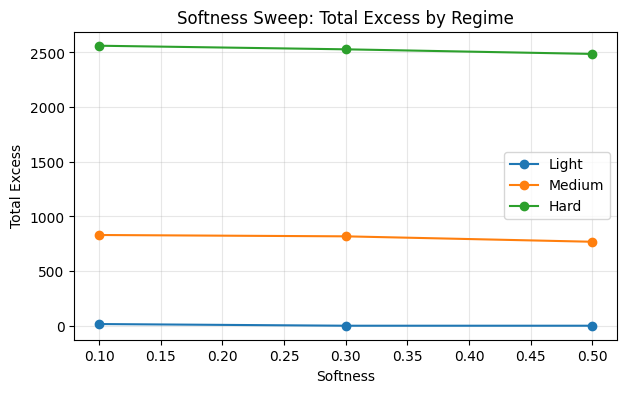

In [252]:
#----------------------------------------------------------------------------------------------------------------
# Visualize how total excess changes with softness for each scenario, comparing against the TOU baseline
#----------------------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt

scenarios_order = ["light", "medium", "hard"]

plt.figure(figsize=(7, 4))

for scenario in scenarios_order:
    subset = soft_df[
        (soft_df["scenario"] == scenario) &
        (soft_df["controller_short"] == "Soft")
    ].sort_values("softness")

    plt.plot(
        subset["softness"],
        subset["total_excess"],
        marker="o",
        label=scenario.capitalize(),
    )

plt.xlabel("Softness")
plt.ylabel("Total Excess")
plt.title("Softness Sweep: Total Excess by Regime")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Softness Sweep Interpretation

**The softness parameter shows a clear regime-dependent effect.**

- In the light regime, increasing softness from 0.1 to 0.3 is enough to eliminate violations and total excess.
- In the medium regime, larger softness values do not improve peak, but they steadily improve ramp and cumulative excess.
- In the hard regime, larger softness still helps, but only by reducing the severity of failure rather than removing overload.

- Overall:
    - softness matters
    - its effect is stronger in easier regimes
    - in harder regimes, softness changes how the system fails rather than whether it fails

## Softness Sweep Conclusion

- The soft controller is not defined only by its existence, but also by its tuning.

    - Softness = 0.1 is generally too stiff.
    - Softness = 0.3 is strong in light regimes.
    - Softness = 0.5 becomes more useful as the regime gets harder.

**This suggests that the best softness value is regime-dependent rather than universal.**

# Part 4: Softness Sweep: Key Finding

**The softness parameter has a clear regime-dependent effect.**

- In the light regime, increasing softness from 0.1 to 0.3 is enough to eliminate feeder violations and total excess.
- In the medium regime, larger softness values do not improve peak, but they steadily improve ramp and cumulative excess.
- In the hard regime, larger softness still helps, but mainly by reducing the severity of failure rather than removing overload.

### Overall, softness is not a cosmetic parameter. Its effect is systematic, and the best softness level depends on regime severity.

## Intermediate Interpretation

At this stage, the two controller families look different in quality:

- **Soft coordination** behaves like a real control strategy: its parameter changes system behavior in a structured, regime-dependent way.
- **Randomized coordination** behaves more like a desynchronization trick: it can help, but its effect is less stable and less reliable.

This makes soft feeder-aware coordination the stronger direction for the next full sweep.

Looking for: /Users/linearityproductions/Desktop/risk_dispatch/results/randomness_sweep_results.csv


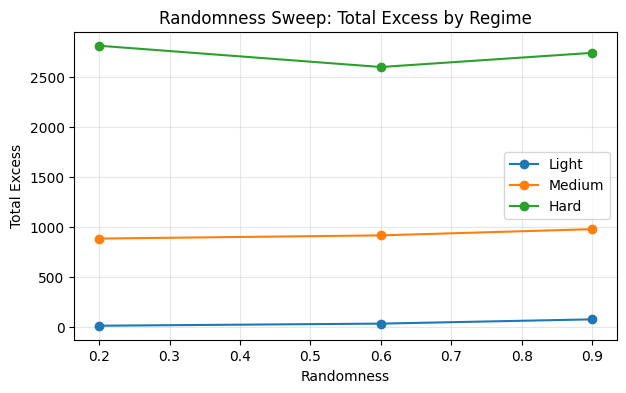

In [253]:
#----------------------------------------------------------------------------------------------------------------
# Visualize how total excess changes with randomness for each scenario, comparing against the TOU baseline
#----------------------------------------------------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

rand_path = Path("../results/randomness_sweep_results.csv").resolve()
print("Looking for:", rand_path)

rand_df = pd.read_csv(rand_path)

rand_df["controller_short"] = rand_df["controller"].replace({
    "Baseline - TOU": "TOU",
    "Randomized TOU": "Randomized",
})

rand_df["randomness"] = rand_df["randomness"].astype(float)

scenarios_order = ["light", "medium", "hard"]

plt.figure(figsize=(7, 4))

for scenario in scenarios_order:
    subset = rand_df[
        (rand_df["scenario"] == scenario) &
        (rand_df["controller_short"] == "Randomized")
    ].sort_values("randomness")

    plt.plot(
        subset["randomness"],
        subset["total_excess"],
        marker="o",
        label=scenario.capitalize(),
    )

plt.xlabel("Randomness")
plt.ylabel("Total Excess")
plt.title("Randomness Sweep: Total Excess by Regime")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Randomness Sweep: Key Finding

The randomness parameter has a non-monotonic effect.

- In light and medium regimes, low randomness (0.2) gives the strongest reduction in peak and ramp.
- In the hard regime, low randomness still reduces peak and ramp, but can worsen violation count and cumulative overload severity.
- High randomness (0.9) is generally weak and often behaves similarly to the uncoordinated baseline.

Overall, randomized control can reduce synchronization, but its tuning is fragile and its behavior is less robust than soft feeder-aware coordination.

# Final Summary

This notebook studied how simple coordination strategies affect aggregate feeder behavior in a multi-battery setting.

### Main findings

- Uncoordinated TOU dispatch creates harmful synchronized behavior, leading to large feeder peaks and significant overload severity.
- Controller performance is regime-dependent: conclusions from a single scenario do not generalize automatically.
- In light regimes, soft feeder-aware coordination performs best overall and can eliminate violations entirely.
- In medium and hard regimes, no simple controller dominates every metric:
  - Hard capping is strongest for reducing peak and ramp.
  - Soft coordination is strongest for reducing cumulative overload severity.
- Randomized coordination can reduce synchronization, but its effect is fragile and less reliable than soft feeder-aware control.
- Violation count alone is not enough to evaluate controller quality; total excess is a more informative metric in stressed regimes.

### Overall conclusion

Simple coordination matters, but its value depends on both the system regime and the performance metric of interest.  
In easier regimes, soft coordination can substantially improve aggregate feeder behavior.  
In harder regimes, simple controllers do not eliminate failure, but instead reshape how the system fails.

## Next Steps

Possible next extensions of this study are:

- full parameter sweeps over softness and randomness across all regimes
- richer synthetic fleets with heterogeneous battery sizes
- use of more realistic load or price profiles
- comparison against more adaptive feeder-aware controllers